In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Explore the Dataset

In [3]:
df = pd.read_csv("titanic_train.csv")
print("First 5 rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())


First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

check data quality

In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows:
0

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


3. Identify the Target Variable


In [5]:
target = "Survived"
print("Target Variable:", target)
print("\nTarget Values:")
print(df[target].value_counts())

Target Variable: Survived

Target Values:
Survived
0    549
1    342
Name: count, dtype: int64


4. Analyze Class Distribution

In [6]:
print(df["Survived"].value_counts())
print("\nClass Distribution (%):")
print(df["Survived"].value_counts(normalize=True) * 100)

Survived
0    549
1    342
Name: count, dtype: int64

Class Distribution (%):
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


5. Visualize Class Imbalance

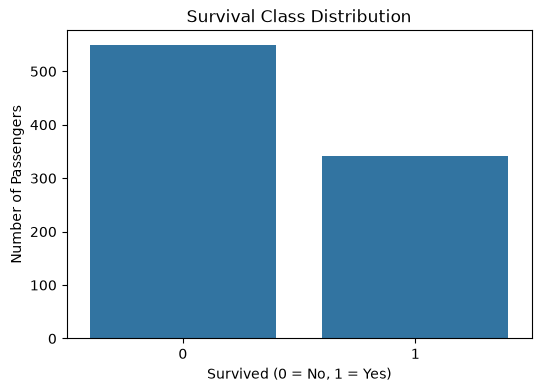

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Class Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

6. Analyze Gender Representation and Display Graph

Gender Representation:
Sex
male      577
female    314
Name: count, dtype: int64


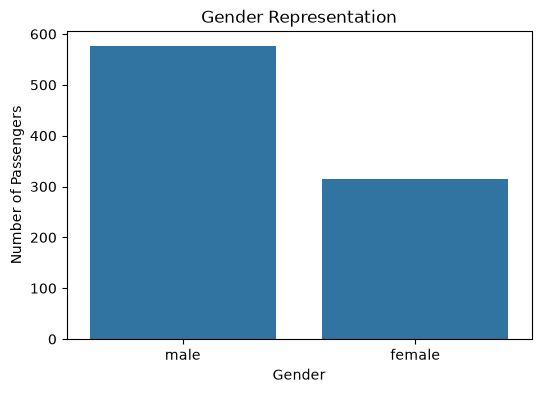

In [8]:
print("Gender Representation:")
print(df["Sex"].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Representation")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

7. Analyze Survival by Gender and Display Graph

Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109


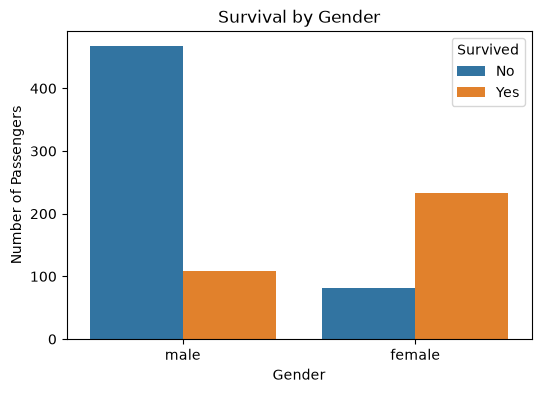

In [9]:
print("Survival by Gender:")
print(pd.crosstab(df["Sex"], df["Survived"]))
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

8. Analyze Passenger-Class Representation and Display Graph

Passenger Class Representation:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


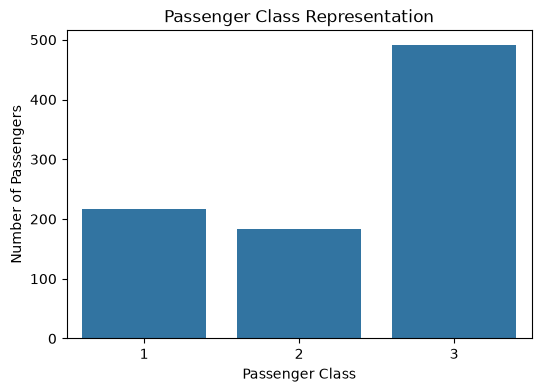

In [10]:
print("Passenger Class Representation:")
print(df["Pclass"].value_counts().sort_index())

plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Representation")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

9. Analyze Survival by Passenger Class and Display Graph

Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


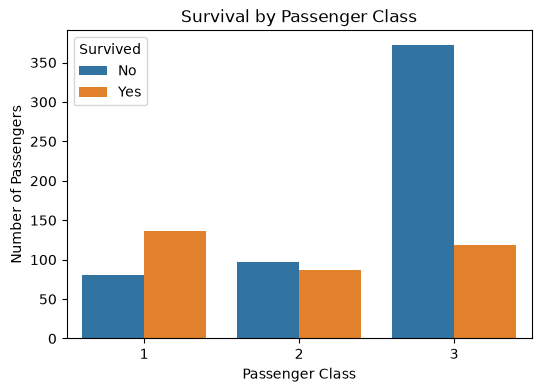

In [11]:
print("Survival by Passenger Class:")
print(pd.crosstab(df["Pclass"], df["Survived"]))

plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

10. Analyze Age Groups

In [12]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 59, 100],
    labels=["Child", "Teenager", "Adult", "Senior"]
)

print("Age Group Distribution:")
print(df["AgeGroup"].value_counts().sort_index())

Age Group Distribution:
AgeGroup
Child        69
Teenager     95
Adult       524
Senior       26
Name: count, dtype: int64


11. Analyze Survival by Age Group and Display Graph

Survival by Age Group:
Survived    0    1
AgeGroup          
Child      29   40
Teenager   56   39
Adult     320  204
Senior     19    7


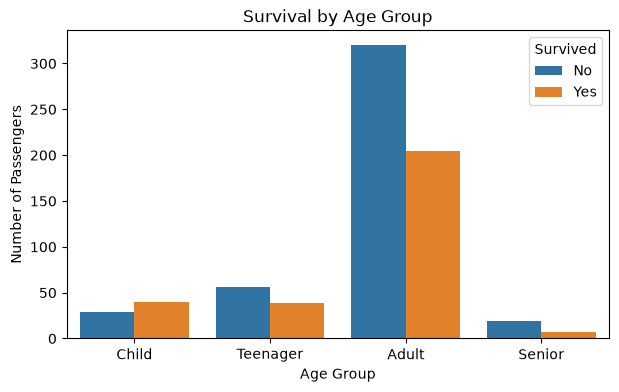

In [13]:
print("Survival by Age Group:")
print(pd.crosstab(df["AgeGroup"], df["Survived"]))

plt.figure(figsize=(7,4))

sns.countplot(
    x="AgeGroup",
    hue="Survived",
    data=df,
    order=["Child", "Teenager", "Adult", "Senior"]
)

plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()